# EfficientNetB0 — Experiment 1: Frozen Backbone (Baseline)
No augmentation. Frozen backbone. Tests how well ImageNet features transfer as-is.

In [1]:
import os, re, json
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight

# ── Paths ───
TRAIN_DIR = "/kaggle/input/datasets/usmanafzaal/strawberry-disease-detection-dataset/train"
VAL_DIR   = "/kaggle/input/datasets/usmanafzaal/strawberry-disease-detection-dataset/val"
TEST_DIR  = "/kaggle/input/datasets/usmanafzaal/strawberry-disease-detection-dataset/test"

# ── Class Names (confirmed from EDA) ────
CLASS_NAMES = [
    'Angular Leafspot',
    'Anthracnose Fruit Rot',
    'Blossom Blight',
    'Gray Mold',
    'Leaf Spot',
    'Powdery Mildew Fruit',
    'Powdery Mildew Leaf'
]

# ── Config ────
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 20
LR         = 1e-3
SEED       = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
print('Setup done.')

2026-03-11 00:22:28.777887: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773188549.187652      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773188549.294413      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773188550.326552      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773188550.326595      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773188550.326600      24 computation_placer.cc:177] computation placer alr

Setup done.


In [2]:
# ── Load Labels from JSON (same method as EDA) ─────────
def load_split(folder):
    data = []
    for f in os.listdir(folder):
        if not f.lower().endswith('.jpg'):
            continue
        img_path  = os.path.join(folder, f)
        json_path = img_path.replace('.jpg', '.json')
        label = None
        if os.path.exists(json_path):
            try:
                with open(json_path) as jf:
                    ann = json.load(jf)
                shapes = ann.get('shapes', [])
                if shapes:
                    label = shapes[0].get('label', None)
            except:
                pass
        if not label:
            name = os.path.splitext(f)[0]
            label = re.sub(r'\d+$', '', name).strip()
        data.append([img_path, label])
    return pd.DataFrame(data, columns=['path', 'label'])

train_df = load_split(TRAIN_DIR)
val_df   = load_split(VAL_DIR)
test_df  = load_split(TEST_DIR)

label2idx   = {name: i for i, name in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)

for df in (train_df, val_df, test_df):
    df['label_idx'] = df['label'].map(label2idx)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')

Train: 1450 | Val: 307 | Test: 743
Classes (7): ['Angular Leafspot', 'Anthracnose Fruit Rot', 'Blossom Blight', 'Gray Mold', 'Leaf Spot', 'Powdery Mildew Fruit', 'Powdery Mildew Leaf']


In [3]:
# ── Class Weights (handles 7.33x imbalance) ────────────
weights = compute_class_weight('balanced',
                                classes=np.arange(NUM_CLASSES),
                                y=train_df['label_idx'].values)
class_weight_dict = dict(enumerate(weights))
print('Class weights:')
for name, idx in label2idx.items():
    print(f'  {name:30s}: {class_weight_dict[idx]:.4f}')

Class weights:
  Angular Leafspot              : 0.8455
  Anthracnose Fruit Rot         : 3.9835
  Blossom Blight                : 1.7554
  Gray Mold                     : 0.8155
  Leaf Spot                     : 0.5437
  Powdery Mildew Fruit          : 2.5573
  Powdery Mildew Leaf           : 0.6494


In [4]:
# ── tf.data Pipeline ───
preprocess = tf.keras.applications.efficientnet.preprocess_input

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    img = preprocess(img)
    return img, label

def make_dataset(df, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (df['path'].values, df['label_idx'].values))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, shuffle=True)
val_ds   = make_dataset(val_df)
test_ds  = make_dataset(test_df)
print('Datasets ready.')

I0000 00:00:1773188612.963971      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773188612.970244      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Datasets ready.


In [5]:
# ── Build Model: Frozen EfficientNetB0 ──────────────────
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
base_model.trainable = False  # All backbone layers frozen

inputs  = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model_exp1 = models.Model(inputs, outputs, name='EfficientNetB0_Exp1')
model_exp1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_exp1.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB0_Exp1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,063,658 (15.50 MB)

 Trainable params: 11,527 (45.03 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [6]:
# ── Train ───
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5,
        restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=2, min_lr=1e-6, verbose=1),
]

history1 = model_exp1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

Epoch 1/20


I0000 00:00:1773188627.148598      68 service.cc:152] XLA service 0x7a1684003930 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773188627.148635      68 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773188627.148640      68 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773188629.607650      68 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-11 00:23:57.383207: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-11 00:23:57.527179: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-11 00:23:57.868600: E external/local_xl

45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.4658 - loss: 1.8722

2026-03-11 00:24:15.485360: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-11 00:24:15.621810: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-11 00:24:15.936256: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-11 00:24:16.077568: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-11 00:24:16.776615: E external/local_xla/xla/stream_

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.4701 - loss: 1.8561

2026-03-11 00:24:34.642505: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-11 00:24:34.783740: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-11 00:24:35.104067: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-11 00:24:35.244912: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-11 00:24:35.938474: E external/local_xla/xla/stream_

46/46 ━━━━━━━━━━━━━━━━━━━━ 62s 754ms/step - accuracy: 0.4742 - loss: 1.8408 - val_accuracy: 0.8241 - val_loss: 0.6733 - learning_rate: 0.0010
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.8834 - loss: 0.4203 - val_accuracy: 0.9121 - val_loss: 0.4037 - learning_rate: 0.0010
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - accuracy: 0.9186 - loss: 0.2562 - val_accuracy: 0.9251 - val_loss: 0.2914 - learning_rate: 0.0010
Epoch 4/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.9309 - loss: 0.2230 - val_accuracy: 0.9414 - val_loss: 0.2300 - learning_rate: 0.0010
Epoch 5/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.9490 - loss: 0.1776 - val_accuracy: 0.9479 - val_loss: 0.1652 - learning_rate: 0.0010
Epoch 6/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.9588 - loss: 0.1606 - val_accuracy: 0.9577 - val_loss: 0.1359 - learning_rate: 0.0010
Epoch 7/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.9674 - loss: 0.1194 - val_accuracy: 0.

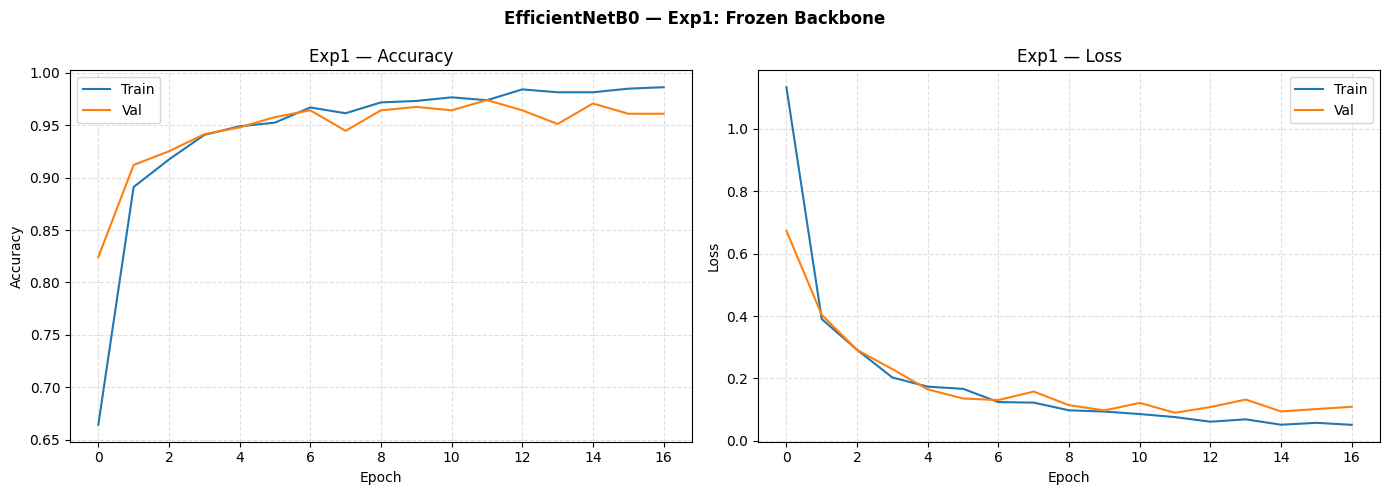

In [7]:
# ── Training Curves ─────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history1.history['accuracy'],     label='Train')
axes[0].plot(history1.history['val_accuracy'], label='Val')
axes[0].set_title('Exp1 — Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(linestyle='--', alpha=0.4)

axes[1].plot(history1.history['loss'],     label='Train')
axes[1].plot(history1.history['val_loss'], label='Val')
axes[1].set_title('Exp1 — Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(linestyle='--', alpha=0.4)

plt.suptitle('EfficientNetB0 — Exp1: Frozen Backbone', fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/exp1_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ── Evaluate on Test Set ────
test_loss, test_acc = model_exp1.evaluate(test_ds, verbose=0)
print(f'[Exp1] Test Loss    : {test_loss:.4f}')
print(f'[Exp1] Test Accuracy: {test_acc:.4f}')

y_true = np.concatenate([y for _, y in test_ds], axis=0)
y_prob = model_exp1.predict(test_ds)
y_pred = np.argmax(y_prob, axis=1)

print('\n[Exp1] Classification Report:')
print(classification_report(y_true, y_pred,
      target_names=CLASS_NAMES, digits=4, zero_division=0))

2026-03-11 00:25:35.908091: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-11 00:25:36.043407: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-11 00:25:36.349691: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-11 00:25:36.490219: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-11 00:25:37.174764: E external/local_xla/xla/stream_

[Exp1] Test Loss    : 0.2712
[Exp1] Test Accuracy: 0.9085
24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 305ms/step

[Exp1] Classification Report:
                       precision    recall  f1-score   support

     Angular Leafspot     0.8683    0.9864    0.9236       147
Anthracnose Fruit Rot     0.7419    0.6765    0.7077        34
       Blossom Blight     0.9841    1.0000    0.9920        62
            Gray Mold     0.8734    0.9517    0.9109       145
            Leaf Spot     0.9921    0.7826    0.8750       161
 Powdery Mildew Fruit     0.7317    0.6977    0.7143        43
  Powdery Mildew Leaf     0.9679    1.0000    0.9837       151

             accuracy                         0.9085       743
            macro avg     0.8799    0.8707    0.8724       743
         weighted avg     0.9124    0.9085    0.9065       743



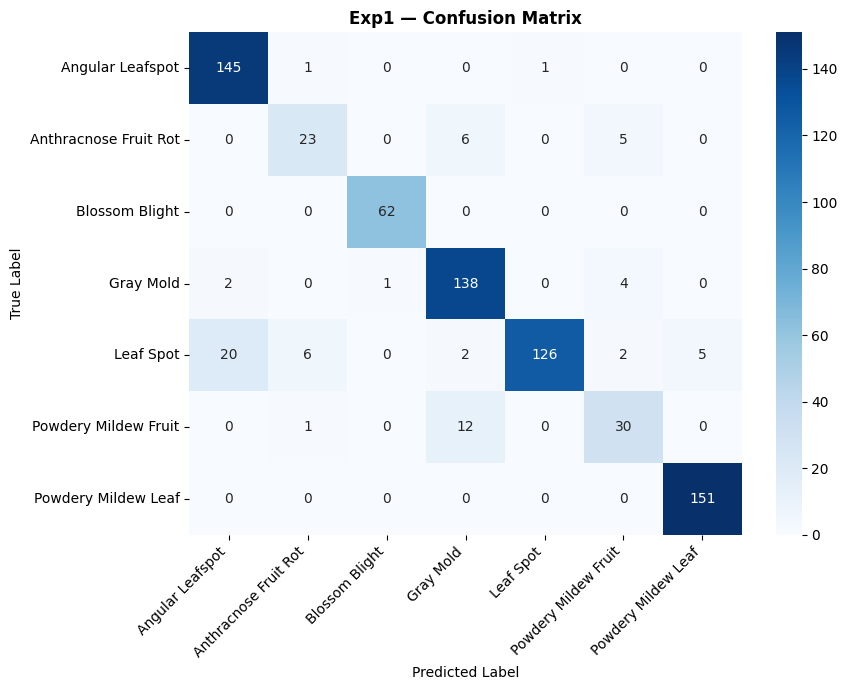

In [9]:
# ── Confusion Matrix ─────
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Exp1 — Confusion Matrix', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/kaggle/working/exp1_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ── Save Model + Results CSV ────
model_exp1.save('/kaggle/working/exp1_efficientnetb0.keras')

exp1_results = {
    'experiment' : 'Exp1 - Frozen',
    'model'      : 'EfficientNetB0',
    'test_acc'   : round(float(test_acc), 4),
    'test_loss'  : round(float(test_loss), 4),
    'f1_weighted': round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4),
    'precision'  : round(precision_score(y_true, y_pred, average='weighted', zero_division=0), 4),
    'recall'     : round(recall_score(y_true, y_pred, average='weighted', zero_division=0), 4),
}
pd.DataFrame([exp1_results]).to_csv('/kaggle/working/exp1_results.csv', index=False)
print('Model and results saved!')
print(exp1_results)

Model and results saved!
{'experiment': 'Exp1 - Frozen', 'model': 'EfficientNetB0', 'test_acc': 0.9085, 'test_loss': 0.2712, 'f1_weighted': 0.9065, 'precision': 0.9124, 'recall': 0.9085}
